# 05 — Toy CNN: Full Corruption Sweep

Same experiment matrix as `04_model_runs.ipynb`, but using the lightweight 3-block toy CNN instead of pretrained backbones. This provides a low-capacity baseline to test whether the corruption robustness pattern is architecture-independent or scales with model capacity.

- **8 corruption types**: none (control), JPEG compression, beam hardening, Gaussian noise, Gibbs ringing, motion ghosting, Rician noise, and combination (all 5 MRI corruptions split equally)
- **3 training corruption fractions**: 0%, 10%, 25%
- **6 test corruption fractions**: 0%, 10%, 25%, 50%, 75%, 100%

Results are saved incrementally to `outputs/model_runs/` alongside the pretrained results.

## 1. Imports & Setup

In [2]:
import sys
import copy
import json
import random
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader

from preprocessing import (
    BrainTumorDataset,
    CLASS_NAMES,
    IMAGE_SIZE,
    get_transform,
    load_split,
)
from corruption_utils import CORRUPTION_REGISTRY, apply_corruption

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Available corruptions: {list(CORRUPTION_REGISTRY)}")
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Device: cuda
Available corruptions: ['jpeg_compression', 'gaussian_noise', 'rician_noise', 'gibbs_ringing', 'motion_ghosting', 'beam_hardening', 'stain_variation', 'tissue_fold', 'air_bubble']
Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Toy CNN Architecture

In [3]:
class ToyCNN(nn.Module):
    """
    Lightweight 3-block CNN for 4-class brain tumor classification.
    Same architecture as notebook 02.
    """

    def __init__(self, num_classes=4, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Sanity check
model = ToyCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
out = model(dummy)
print(f"Output shape: {tuple(out.shape)}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters()):,}")
del model, dummy, out

Output shape: (2, 4)
Parameters:   94,212


## 3. Configuration

In [4]:
# =====================================================================
# CONFIGURATION
# =====================================================================

MODEL_NAME = "toy_cnn"

CORRUPTION_TYPES = [
    "none",
    "jpeg_compression",
    "beam_hardening",
    "gaussian_noise",
    "gibbs_ringing",
    "motion_ghosting",
    "rician_noise",
    "combination",
]

TRAIN_FRACTIONS = [0.0, 0.10, 0.25]
TEST_FRACTIONS = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]

# Toy CNN uses a higher learning rate than the pretrained models
NUM_EPOCHS = 15
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4

RESULTS_DIR = PROJECT_ROOT / "outputs" / "model_runs"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Build experiment list
experiments = []
for ct in CORRUPTION_TYPES:
    if ct == "none":
        experiments.append((ct, 0.0, [0.0]))
    else:
        for tf in TRAIN_FRACTIONS:
            experiments.append((ct, tf, TEST_FRACTIONS))

n_trainings = len(experiments)
n_evals = sum(len(tfs) for _, _, tfs in experiments)
print(f"Model:               {MODEL_NAME}")
print(f"Corruption types:    {len(CORRUPTION_TYPES)}")
print(f"Training fractions:  {TRAIN_FRACTIONS}")
print(f"Test fractions:      {TEST_FRACTIONS}")
print(f"---")
print(f"Total trainings:     {n_trainings}")
print(f"Total evaluations:   {n_evals}")

Model:               toy_cnn
Corruption types:    8
Training fractions:  [0.0, 0.1, 0.25]
Test fractions:      [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
---
Total trainings:     22
Total evaluations:   127


## 4. Corruption Datasets & DataLoader Helpers

In [5]:
COMBINATION_CORRUPTIONS = [
    "beam_hardening",
    "gaussian_noise",
    "gibbs_ringing",
    "motion_ghosting",
    "rician_noise",
]


class CorruptedBrainTumorDataset(BrainTumorDataset):
    """Corrupts a random fraction of samples with a single corruption type."""

    def __init__(self, samples, transform, corruption_name, corruption_fraction=0.0, seed=42):
        super().__init__(samples, transform)
        self.corruption_name = corruption_name
        n_corrupt = int(len(samples) * corruption_fraction)
        rng = random.Random(seed)
        all_indices = list(range(len(samples)))
        rng.shuffle(all_indices)
        self.corrupted_indices = set(all_indices[:n_corrupt])

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        if idx in self.corrupted_indices:
            image = apply_corruption(image, self.corruption_name)
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class CombinedCorruptionDataset(BrainTumorDataset):
    """Splits the corrupted portion equally across all 5 MRI corruption types."""

    def __init__(self, samples, transform, corruption_fraction=0.0, seed=42):
        super().__init__(samples, transform)
        n_corrupt = int(len(samples) * corruption_fraction)
        rng = random.Random(seed)
        all_indices = list(range(len(samples)))
        rng.shuffle(all_indices)
        corrupt_indices = all_indices[:n_corrupt]

        self.index_to_corruption = {}
        chunk_size = max(1, len(corrupt_indices) // len(COMBINATION_CORRUPTIONS))
        for i, corruption_name in enumerate(COMBINATION_CORRUPTIONS):
            start = i * chunk_size
            end = start + chunk_size if i < len(COMBINATION_CORRUPTIONS) - 1 else len(corrupt_indices)
            for idx in corrupt_indices[start:end]:
                self.index_to_corruption[idx] = corruption_name

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        if idx in self.index_to_corruption:
            image = apply_corruption(image, self.index_to_corruption[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_dataloader(split, corruption_type, corruption_fraction, batch_size):
    """Build a DataLoader with the specified corruption settings."""
    samples = load_split(split)
    transform = get_transform(split)

    if corruption_type == "none" or corruption_fraction == 0.0:
        dataset = BrainTumorDataset(samples, transform)
    elif corruption_type == "combination":
        dataset = CombinedCorruptionDataset(
            samples, transform,
            corruption_fraction=corruption_fraction, seed=SEED,
        )
    else:
        dataset = CorruptedBrainTumorDataset(
            samples, transform,
            corruption_name=corruption_type,
            corruption_fraction=corruption_fraction, seed=SEED,
        )

    return DataLoader(
        dataset, batch_size=batch_size,
        shuffle=(split == "train"), num_workers=0,
    )


print("Dataset helpers ready.")

Dataset helpers ready.


## 5. Training & Evaluation

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_with_predictions(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return running_loss / total, correct / total, all_preds, all_labels


def run_single_experiment(corruption_type, train_fraction, test_fractions,
                          num_epochs, batch_size, lr, weight_decay, device):
    """Train a fresh ToyCNN and evaluate on all test fractions."""
    train_loader = build_dataloader("train", corruption_type, train_fraction, batch_size)
    val_loader = build_dataloader("val", "none", 0.0, batch_size)

    model = ToyCNN(num_classes=len(CLASS_NAMES)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = []
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == num_epochs:
            print(f"    Epoch {epoch:>3}/{num_epochs} \u2014 "
                  f"train_acc: {train_acc:.3f} | val_acc: {val_acc:.3f} | {elapsed:.1f}s")

    model.load_state_dict(best_model_state)

    test_results = {}
    for test_frac in test_fractions:
        test_loader = build_dataloader("test", corruption_type, test_frac, batch_size)
        test_loss, test_acc, preds, labels = evaluate_with_predictions(
            model, test_loader, criterion, device
        )
        per_class = {}
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            cls_mask = [i for i, l in enumerate(labels) if l == cls_idx]
            if cls_mask:
                cls_correct = sum(1 for i in cls_mask if preds[i] == labels[i])
                per_class[cls_name] = cls_correct / len(cls_mask)
            else:
                per_class[cls_name] = 0.0

        test_results[str(test_frac)] = {
            "test_loss": test_loss,
            "test_acc": test_acc,
            "per_class_acc": per_class,
            "predictions": preds,
            "labels": labels,
        }
        print(f"    Test ({test_frac:>5.0%} corrupted): acc={test_acc:.4f}")

    return {
        "model_name": MODEL_NAME,
        "corruption_type": corruption_type,
        "train_fraction": train_fraction,
        "best_val_acc": best_val_acc,
        "history": history,
        "test_results": test_results,
    }


print("Training functions ready.")

Training functions ready.


## 6. Run Full Sweep

In [7]:
def get_results_path():
    return RESULTS_DIR / f"{MODEL_NAME}_full_results.json"


def load_existing_results():
    path = get_results_path()
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}


def save_results(all_results):
    path = get_results_path()
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)


def make_key(corruption_type, train_fraction):
    return f"{corruption_type}__train{train_fraction:.2f}"


# ---------- Main sweep ----------
sweep_start = time.time()

print(f"{'='*70}")
print(f"  MODEL: {MODEL_NAME}")
print(f"{'='*70}")

all_results = load_existing_results()
total = len(experiments)

for i, (corruption_type, train_fraction, test_fracs) in enumerate(experiments, 1):
    key = make_key(corruption_type, train_fraction)

    if key in all_results:
        print(f"\n  [{i}/{total}] SKIP (done): {key}")
        continue

    print(f"\n  [{i}/{total}] {MODEL_NAME} | {corruption_type} | train={train_fraction:.0%}")

    result = run_single_experiment(
        corruption_type=corruption_type,
        train_fraction=train_fraction,
        test_fractions=test_fracs,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        device=DEVICE,
    )

    all_results[key] = result
    save_results(all_results)
    print(f"    Saved. Best val acc: {result['best_val_acc']:.4f}")

sweep_elapsed = time.time() - sweep_start
print(f"\n{'='*70}")
print(f"SWEEP COMPLETE  ({sweep_elapsed/60:.1f} min)")
print(f"Results: {get_results_path()}")
print(f"{'='*70}")

  MODEL: toy_cnn

  [1/22] toy_cnn | none | train=0%
    Epoch   5/15 — train_acc: 0.753 | val_acc: 0.451 | 21.6s
    Epoch  10/15 — train_acc: 0.798 | val_acc: 0.774 | 21.8s
    Epoch  15/15 — train_acc: 0.825 | val_acc: 0.858 | 21.9s
    Test (   0% corrupted): acc=0.7756
    Saved. Best val acc: 0.8580

  [2/22] toy_cnn | jpeg_compression | train=0%
    Epoch   5/15 — train_acc: 0.756 | val_acc: 0.596 | 21.7s
    Epoch  10/15 — train_acc: 0.790 | val_acc: 0.522 | 21.7s
    Epoch  15/15 — train_acc: 0.821 | val_acc: 0.867 | 21.8s
    Test (   0% corrupted): acc=0.7706
    Test (  10% corrupted): acc=0.7700
    Test (  25% corrupted): acc=0.7681
    Test (  50% corrupted): acc=0.7706
    Test (  75% corrupted): acc=0.7681
    Test ( 100% corrupted): acc=0.7612
    Saved. Best val acc: 0.8670

  [3/22] toy_cnn | jpeg_compression | train=10%
    Epoch   5/15 — train_acc: 0.740 | val_acc: 0.581 | 22.5s
    Epoch  10/15 — train_acc: 0.797 | val_acc: 0.640 | 22.6s
    Epoch  15/15 — train_

## 7. Load & Analyze Results

In [8]:
import pandas as pd


def load_toy_results():
    """Load toy CNN results into a DataFrame."""
    rows = []
    path = get_results_path()
    if not path.exists():
        print(f"  No results found at {path}")
        return pd.DataFrame()
    with open(path) as f:
        data = json.load(f)
    for key, result in data.items():
        for test_frac_str, test_res in result["test_results"].items():
            rows.append({
                "model": result["model_name"],
                "corruption_type": result["corruption_type"],
                "train_fraction": result["train_fraction"],
                "test_fraction": float(test_frac_str),
                "best_val_acc": result["best_val_acc"],
                "test_acc": test_res["test_acc"],
                "test_loss": test_res["test_loss"],
            })
    return pd.DataFrame(rows)


df = load_toy_results()
print(f"Total result rows: {len(df)}")
print(f"Corruption types: {sorted(df['corruption_type'].unique())}")
print(f"Train fractions: {sorted(df['train_fraction'].unique())}")
print(f"Test fractions: {sorted(df['test_fraction'].unique())}")

# Summary table
pivot_val = df.drop_duplicates(
    subset=["corruption_type", "train_fraction"]
).pivot_table(
    index="corruption_type",
    columns="train_fraction",
    values="best_val_acc",
    aggfunc="first",
)
print("\n=== Best Validation Accuracy ===")
print(pivot_val.to_string(float_format="{:.4f}".format))

Total result rows: 127
Corruption types: ['beam_hardening', 'combination', 'gaussian_noise', 'gibbs_ringing', 'jpeg_compression', 'motion_ghosting', 'none', 'rician_noise']
Train fractions: [np.float64(0.0), np.float64(0.1), np.float64(0.25)]
Test fractions: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

=== Best Validation Accuracy ===
train_fraction     0.00   0.10   0.25
corruption_type                      
beam_hardening   0.8554 0.8589 0.8518
combination      0.8616 0.8438 0.8473
gaussian_noise   0.8616 0.8393 0.8384
gibbs_ringing    0.8589 0.8607 0.8589
jpeg_compression 0.8670 0.8518 0.8482
motion_ghosting  0.8554 0.8562 0.8411
none             0.8580    NaN    NaN
rician_noise     0.8670 0.8518 0.8455


## 8. Visualization: Test Accuracy vs Test Corruption

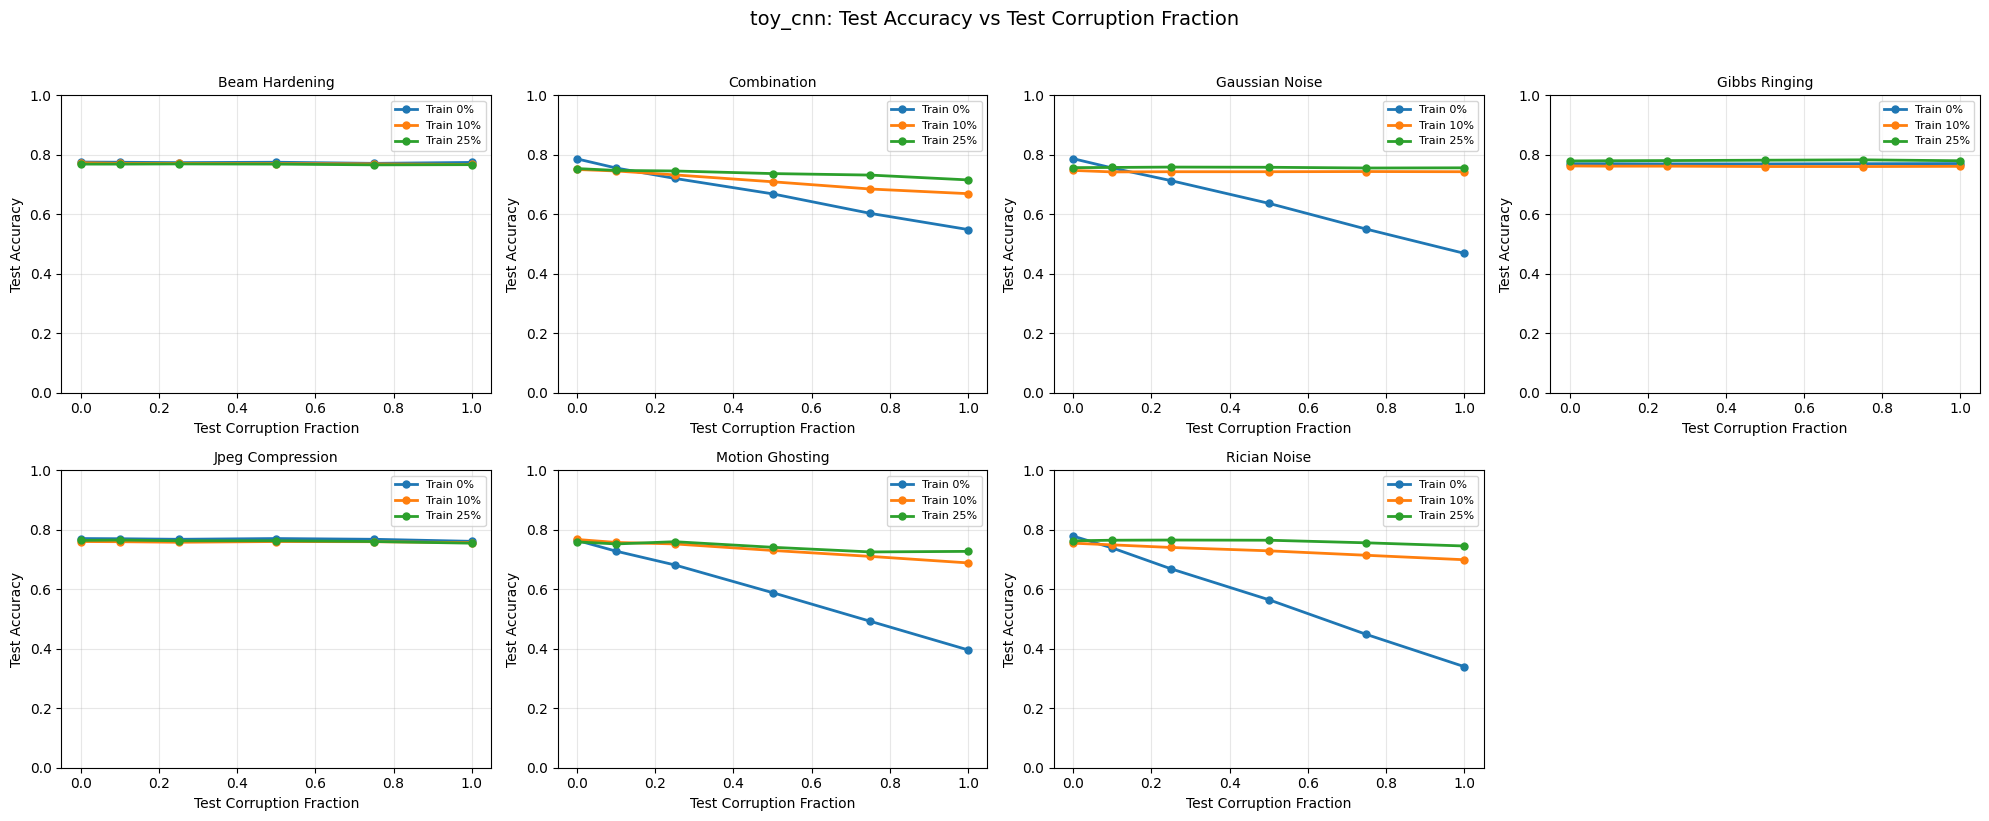

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\toy_cnn_corruption_comparison.png


In [9]:
import matplotlib.pyplot as plt


corruption_types = sorted(df[df["corruption_type"] != "none"]["corruption_type"].unique())
n = len(corruption_types)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
fig.suptitle(f"{MODEL_NAME}: Test Accuracy vs Test Corruption Fraction",
             fontsize=14, y=1.02)

for idx, ct in enumerate(corruption_types):
    ax = axes[idx // cols][idx % cols]
    ct_df = df[df["corruption_type"] == ct]

    for tf in sorted(ct_df["train_fraction"].unique()):
        subset = ct_df[ct_df["train_fraction"] == tf].sort_values("test_fraction")
        ax.plot(subset["test_fraction"], subset["test_acc"],
                "o-", linewidth=2, markersize=5, label=f"Train {tf:.0%}")

    ax.set_title(ct.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Test Corruption Fraction")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for idx in range(n, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

plt.tight_layout()
plot_path = RESULTS_DIR / f"{MODEL_NAME}_corruption_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## 9. Robustness Heatmap

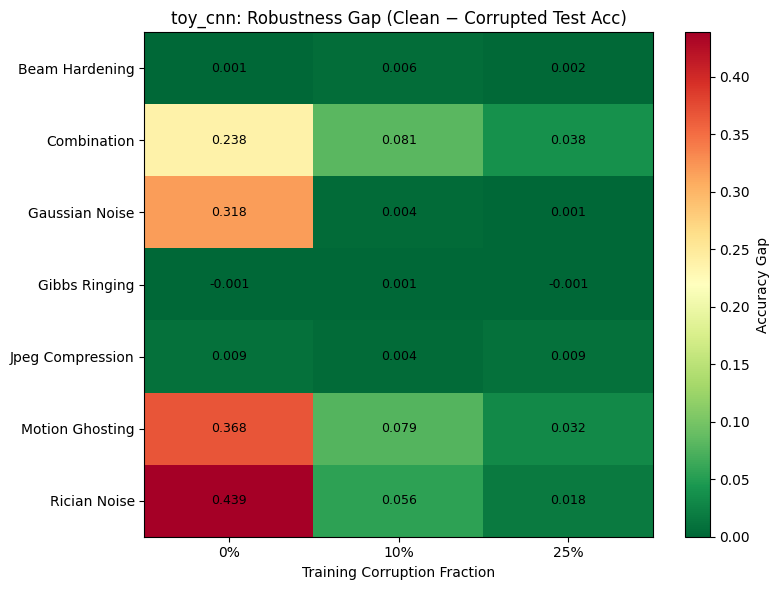

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\toy_cnn_robustness_heatmap.png


In [10]:
heatmap_df = df[(df["corruption_type"] != "none")]

clean = heatmap_df[heatmap_df["test_fraction"] == 0.0].copy()
corrupt = heatmap_df[heatmap_df["test_fraction"] == 1.0].copy()

merged = clean.merge(
    corrupt[["corruption_type", "train_fraction", "test_acc"]],
    on=["corruption_type", "train_fraction"],
    suffixes=("_clean", "_corrupt"),
)
merged["robustness_gap"] = merged["test_acc_clean"] - merged["test_acc_corrupt"]

pivot = merged.pivot_table(
    index="corruption_type",
    columns="train_fraction",
    values="robustness_gap",
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto", vmin=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.0%}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([n.replace("_", " ").title() for n in pivot.index])
ax.set_xlabel("Training Corruption Fraction")
ax.set_title(f"{MODEL_NAME}: Robustness Gap (Clean \u2212 Corrupted Test Acc)")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, label="Accuracy Gap")
plt.tight_layout()
plot_path = RESULTS_DIR / f"{MODEL_NAME}_robustness_heatmap.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## 10. Compare Toy CNN vs Pretrained Models

Load the pretrained results from notebook 04 and overlay the toy CNN results to see how model capacity affects corruption robustness.

In [11]:
# Load pretrained results from notebook 04
PRETRAINED_MODELS = ["resnet18", "resnet50", "densenet121"]


def load_pretrained_results():
    rows = []
    for model_name in PRETRAINED_MODELS:
        path = RESULTS_DIR / f"{model_name}_full_results.json"
        if not path.exists():
            print(f"  Warning: no results for {model_name}")
            continue
        with open(path) as f:
            data = json.load(f)
        for key, result in data.items():
            for test_frac_str, test_res in result["test_results"].items():
                rows.append({
                    "model": result["model_name"],
                    "corruption_type": result["corruption_type"],
                    "train_fraction": result["train_fraction"],
                    "test_fraction": float(test_frac_str),
                    "best_val_acc": result["best_val_acc"],
                    "test_acc": test_res["test_acc"],
                    "test_loss": test_res["test_loss"],
                })
    return pd.DataFrame(rows)


pretrained_df = load_pretrained_results()
combined_df = pd.concat([df, pretrained_df], ignore_index=True)

print(f"Toy CNN rows:      {len(df)}")
print(f"Pretrained rows:   {len(pretrained_df)}")
print(f"Combined rows:     {len(combined_df)}")
print(f"Models available:  {sorted(combined_df['model'].unique())}")

Toy CNN rows:      127
Pretrained rows:   381
Combined rows:     508
Models available:  ['densenet121', 'resnet18', 'resnet50', 'toy_cnn']


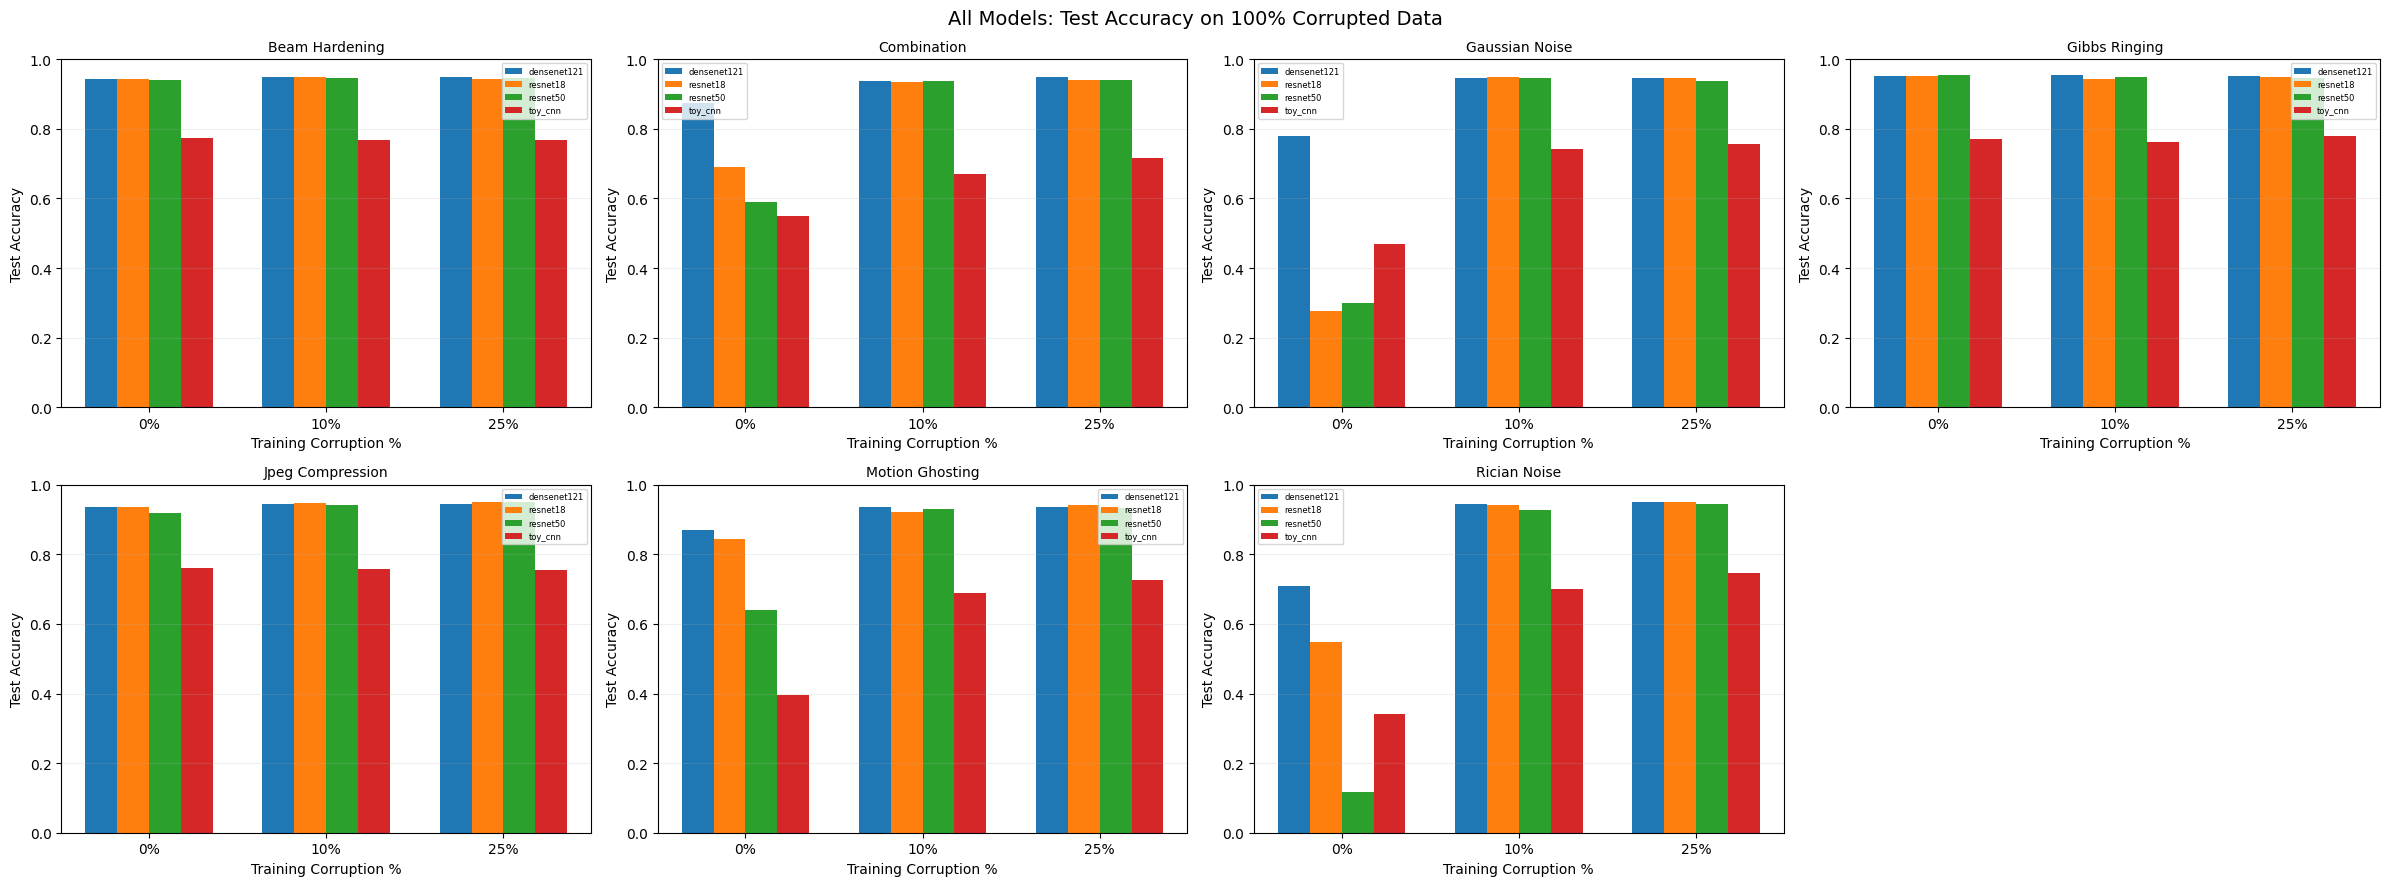

Saved: c:\Users\xethr\GitHub\badnets-medical-imaging\outputs\model_runs\all_models_comparison.png


In [12]:
# Compare all models on 100% corrupted test data at each training fraction
plot_df = combined_df[
    (combined_df["corruption_type"] != "none") &
    (combined_df["test_fraction"] == 1.0)
]

corruption_types = sorted(plot_df["corruption_type"].unique())
train_fracs = sorted(plot_df["train_fraction"].unique())
models = sorted(plot_df["model"].unique())

n = len(corruption_types)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows), squeeze=False)
fig.suptitle("All Models: Test Accuracy on 100% Corrupted Data", fontsize=14)

for idx, ct in enumerate(corruption_types):
    ax = axes[idx // cols][idx % cols]
    ct_df = plot_df[plot_df["corruption_type"] == ct]

    x = range(len(train_fracs))
    width = 0.18
    for j, model_name in enumerate(models):
        model_ct_df = ct_df[ct_df["model"] == model_name]
        accs = []
        for tf in train_fracs:
            row = model_ct_df[model_ct_df["train_fraction"] == tf]
            accs.append(row["test_acc"].values[0] if len(row) > 0 else 0)
        offset = (j - len(models) / 2 + 0.5) * width
        ax.bar([xi + offset for xi in x], accs, width, label=model_name)

    ax.set_title(ct.replace("_", " ").title(), fontsize=10)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{tf:.0%}" for tf in train_fracs])
    ax.set_xlabel("Training Corruption %")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.2, axis="y")

for idx in range(n, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

plt.tight_layout()
plot_path = RESULTS_DIR / "all_models_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

In [13]:
# Summary: average robustness gap per model (across all corruption types, train=25%)
summary_df = combined_df[
    (combined_df["corruption_type"] != "none") &
    (combined_df["train_fraction"] == 0.25)
]

clean_summary = summary_df[summary_df["test_fraction"] == 0.0][["model", "corruption_type", "test_acc"]]
corrupt_summary = summary_df[summary_df["test_fraction"] == 1.0][["model", "corruption_type", "test_acc"]]

gap_df = clean_summary.merge(
    corrupt_summary, on=["model", "corruption_type"], suffixes=("_clean", "_corrupt")
)
gap_df["gap"] = gap_df["test_acc_clean"] - gap_df["test_acc_corrupt"]

print("=== Average Robustness Gap (train=25%, clean vs 100% corrupted) ===")
print(gap_df.groupby("model")["gap"].mean().sort_values().to_string(float_format="{:.4f}".format))
print("\n(Lower gap = more robust)")

=== Average Robustness Gap (train=25%, clean vs 100% corrupted) ===
model
densenet121   0.0034
resnet18      0.0055
resnet50      0.0065
toy_cnn       0.0141

(Lower gap = more robust)
